In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
import matplotlib.pyplot as plt
from aicsimageio import AICSImage
import platform
from scipy.ndimage import gaussian_filter


sys.path.append(os.path.abspath(os.path.join(os.pardir, 'src')))
from data_processing import *


**GENERAL PROCEDURE**

-1) This runs at the leica-env<br />
0) Use the loader2 function to extract images from Leica file system
1) Launch napari (in a different terminal start micro-sam conda env (conda activate micro-sam) and there launch napari (just type napari, then Enter)).
2) Load images in Napari: File, Load Files as Stack...
3) Find the frames where the Antennal Lobes (AL) are visible before .
4) Make masks out of these selected frames by:
    a)

In [2]:
loader2('2026_05_26','Gerardo',False, False)

/home/gerard/data/confocal/2026_05_26_Gerardo
Number of series: 3
series 0: shape = (1, 3, 110, 512, 512)
series 1: shape = (1, 3, 110, 512, 512)
series 2: shape = (1, 3, 18, 512, 512)


In [32]:
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', scene=0)
print(dictMD)
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', scene=1)
print(dictMD)
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2026_05_26_Gerardo/Project.lif', scene=2)
print(dictMD)
dictMD = parse_lif_psf_params('/home/gerard/data/confocal/2025_12_06_Gerardo/Project.lif', scene=2)
print(dictMD)


{'NA': 1.4, 'n': 1.518, 'voxel_z_um': 0.5344549541284404, 'voxel_xy_um': 0.36110332681017615, 'emission_nm': [529.0, 659.0, 796.5]}
{'NA': 1.4, 'n': 1.518, 'voxel_z_um': 0.29222, 'voxel_xy_um': 0.022568962818003916, 'emission_nm': [529.0, 659.0, 796.5]}
{'NA': 1.4, 'n': 1.518, 'voxel_z_um': 0.66134, 'voxel_xy_um': 0.022568962818003916, 'emission_nm': [529.0, 659.0, 796.5]}
{'NA': 1.3, 'n': 1.518, 'voxel_z_um': 0.9997, 'voxel_xy_um': 0.7109223091976516, 'emission_nm': [602.5, 716.0, 796.5]}


In [7]:
system = platform.system()


if system == 'Linux':
    home = '/home/'
elif system == 'Darwin':
    home = '/Users/'
path_data = 'gerard/data/confocal/2026_05_26_Gerardo/Project.lif'
path_data_all = home + path_data #os.path.join(home, )

residual_reprojection= {}
scenes = [
        #0,
        1,
        #2
        ]

channels = [0,1,2]

iterations = [
            # 1,        
            # 2,
            # 3,
            # 4,
            # 5,
            6,
            # 7, 
            #10, 
            # 15,
            #20
            ]

img = AICSImage(path_data_all)
for scene in scenes:
    img.set_scene(img.scenes[scene])
    for channel in channels:   
        stack = img.get_image_data("ZYX", T=0, C=channel)
        for num_iter in iterations:
            background_noise_ratios = []
            result, sigma_xy_px = deconvolve(stack, path_data_all, channel=channel, scene=scene, num_iter=num_iter)
            
            #take frame 50 and calculate the Residual re-projection, store it.
            scene_channel_key = 'scn' +  str(scene) + '_ch'+ str(channel)
            iterations_num_key = 'n_iter'+ str(num_iter)
            
            re_blurred = gaussian_filter(result[50].astype(float), sigma=sigma_xy_px)
            residual = stack[50].astype(float) - re_blurred
            
            if scene_channel_key not in residual_reprojection:
                residual_reprojection[scene_channel_key] = {}
            
            residual_reprojection[scene_channel_key][iterations_num_key] = residual
            
            #per-frame ratio
            
            for z in range(result.shape[0]):
                ratio = result[z].max() / stack[z].max() + 1e-9
                if ratio > 5:
                    print(f'Frame{z}: peak increased {ratio:2f}x - possible noise spike')
                   
                bg_mask = stack[z] < np.percentile(stack[z], 10)
                
                # bg_orig_std == 0 means a flat/dark frame (e.g. all-zero edge slices).
                # After deconv to float32 those pixels get tiny non-zero values, so the
                # ratio blows up — not a real deconvolution problem, skip these frames.
                if bg_mask.sum() < 2:
                    background_noise_ratios.append(0)
                    continue
                
                bg_orig_std = stack[z][bg_mask].std()          # ← only called when safe
                
                if bg_orig_std == 0:
                    background_noise_ratios.append(0)
                    continue

                noise_ratio = result[z][bg_mask].std() / bg_orig_std
                
                if noise_ratio > 1.5:
                    background_noise_ratios.append(1)
                else:
                    background_noise_ratios.append(0)
                
            print(f'about {sum(background_noise_ratios)/len(background_noise_ratios):.3f} maybe with problems')
            # ratio = result.max() / stack.max()
            # if ratio > 5:
            #     print(f"Warning: peak intensity increased {ratio:.1f}x — possible noise amplification")

PSF (ch0): λ=519 nm | σ_xy=0.078 µm (3.45 px) | σ_z=0.265 µm (0.91 px) → 2D-per-frame (σ_z=0.91 px < 2, Z undersampled)
2026_05_26_s1_ch0_deconv_iter_6.tif
about 0.482 maybe with problems
PSF (ch1): λ=670 nm | σ_xy=0.101 µm (4.45 px) | σ_z=0.342 µm (1.17 px) → 2D-per-frame (σ_z=1.17 px < 2, Z undersampled)
2026_05_26_s1_ch1_deconv_iter_6.tif
about 0.000 maybe with problems
PSF (ch2): λ=573 nm | σ_xy=0.086 µm (3.81 px) | σ_z=0.293 µm (1.00 px) → 2D-per-frame (σ_z=1.00 px < 2, Z undersampled)
2026_05_26_s1_ch2_deconv_iter_6.tif
about 0.300 maybe with problems


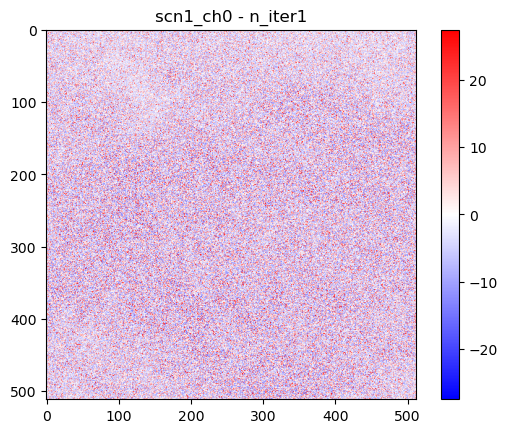

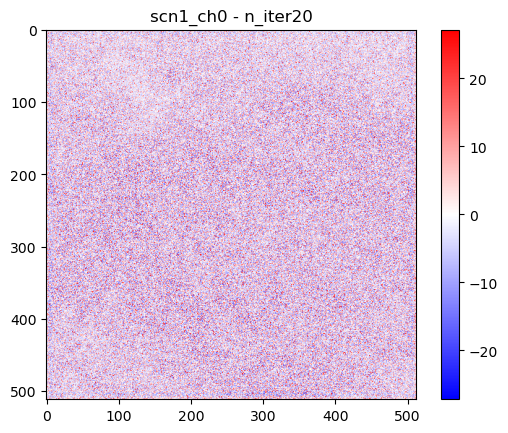

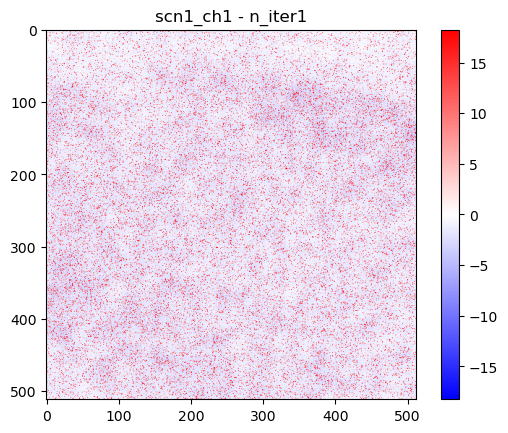

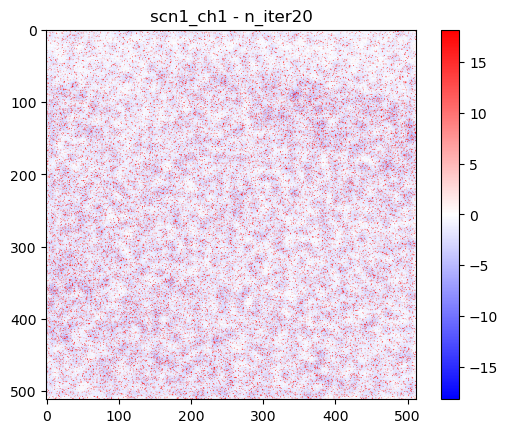

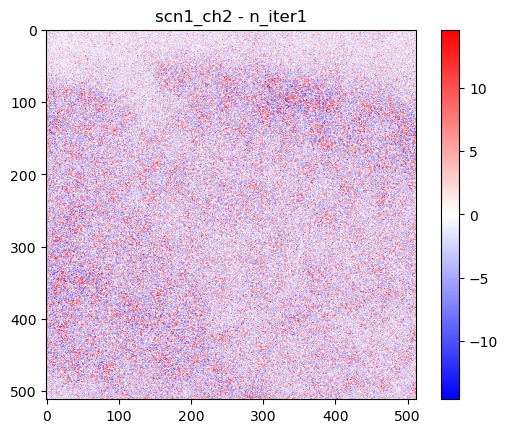

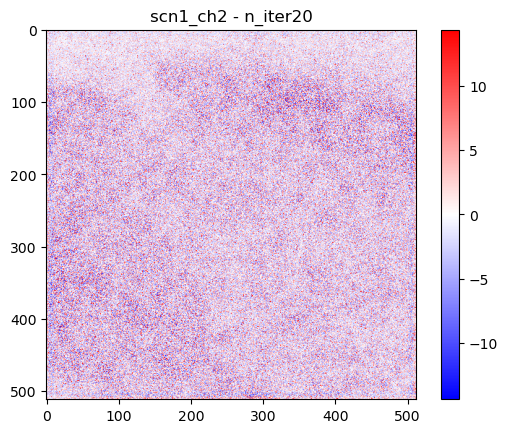

In [34]:
#residual_reprojection['scn1_ch0'].keys()

for key1 in residual_reprojection.keys():
    
    for key2 in residual_reprojection[key1].keys():
        residual = residual_reprojection[key1][key2]
        
        
        plt.figure()  # Create a new figure
        plt.imshow(residual, cmap='bwr', vmin=-residual.std()*3, vmax=residual.std()*3)
        plt.title(f'{key1} - {key2}')  # Add title to identify the image
        plt.colorbar()
        plt.show()  # Show each image
        
        
        #plt.imshow(residual, cmap='bwr', vmin=-residual.std()*3, vmax=residual.std()*3)

    